In [2]:
%matplotlib ipympl

import matplotlib.pyplot as plt
from matplotlib import animation

import numpy as np

from ca.rule import BirthSurvive
from ca.neighborhood import Neighborhood
from ca.generator import Generator

In [3]:
# Initialize different Cellular Automata
g1 = Generator(BirthSurvive.GOL)
g2 = Generator(BirthSurvive.B34S23)
g3 = Generator(BirthSurvive.B35S23)
g4 = Generator(BirthSurvive.Custom(range(3, 6), range(2, 5)))
g5 = Generator(BirthSurvive.Custom(range(3, 4), range(2, 4), Neighborhood.Custom([[1, 0, 1], [0, 0, 0], [1, 0, 1]])))

g = [g1, g2, g3, g4, g5]

d1 = []
d2 = []
d3 = []
d4 = []
d5 = []

d = [d1, d2, d3, d4, d5]

In [14]:
# Collect Data
num_epochs = 100

for _ in range(num_epochs):
    for i in range(len(g)):
        d[i].append(g[i].step())

d = np.array(d)

In [15]:
# Select Automaton for Analysis
results = d[4]

# Animation of the Cellular Automaton

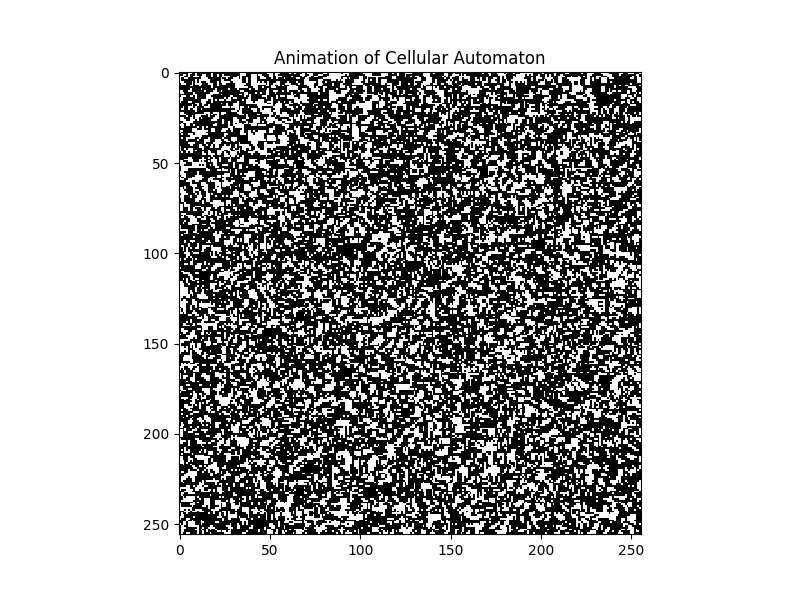

In [7]:
plt.close("all")

fig, ax = plt.subplots(figsize=(8, 6), num=" ")

img = ax.imshow(results[0], cmap='binary', interpolation='nearest')

ax.set_title("Animation of Cellular Automaton")

# Keyframe update
def update(frame):
    img.set_data(results[frame])    
    return img

ani = animation.FuncAnimation(fig, update, frames=num_epochs, interval=100, blit=True, repeat=False)

plt.show()

# Analysis of the Cellular Automaton

In [16]:
# General Stats
mean = np.mean(results)
std = np.std(results)
var = np.var(results)

print(f"mean: {mean} | std: {std} | var: {var} | n: {num_epochs}")

flat_results = results.reshape(num_epochs, -1)

unique_keys, _ = np.unique(flat_results, axis=0, return_counts=True)

num_unique = len(unique_keys)
num_duplicate = num_epochs - num_unique

print(f"unique-keys: {num_unique} | duplicate-keys: {num_duplicate}")

mean: 0.15356948852539062 | std: 0.36053557483199977 | var: 0.1299859007194405 | n: 100
unique-keys: 6 | duplicate-keys: 94


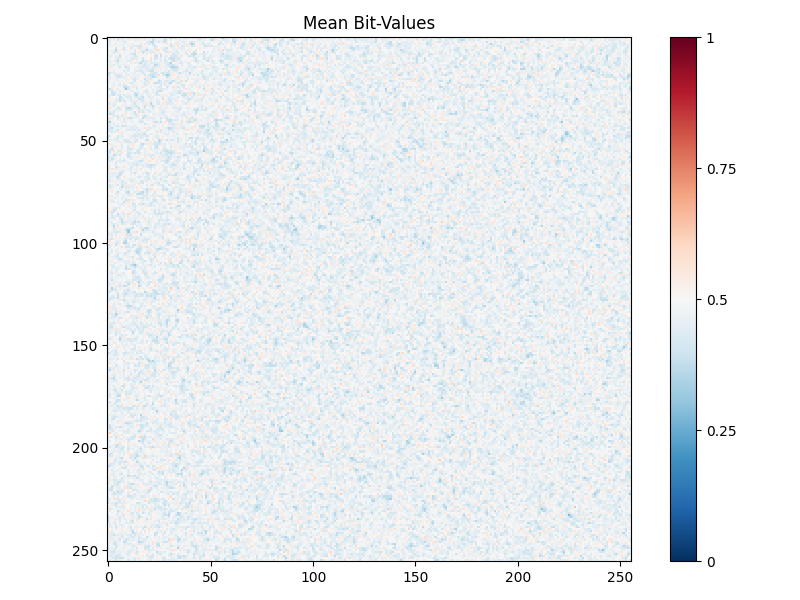

In [9]:
plt.close("all")

mean_bit_values = np.mean(results, axis=0)

fig, ax = plt.subplots(figsize=(8, 6), num=" ")

img = ax.imshow(mean_bit_values, cmap="RdBu_r", vmin=0.0, vmax=1.0, interpolation="nearest")

ax.set_title(f"Mean Bit-Values")

# Legend:
cbar = fig.colorbar(img, ax=ax)
cbar.set_ticks([0.0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(["0", "0.25", "0.5", "0.75", "1"])

plt.tight_layout()
plt.show()

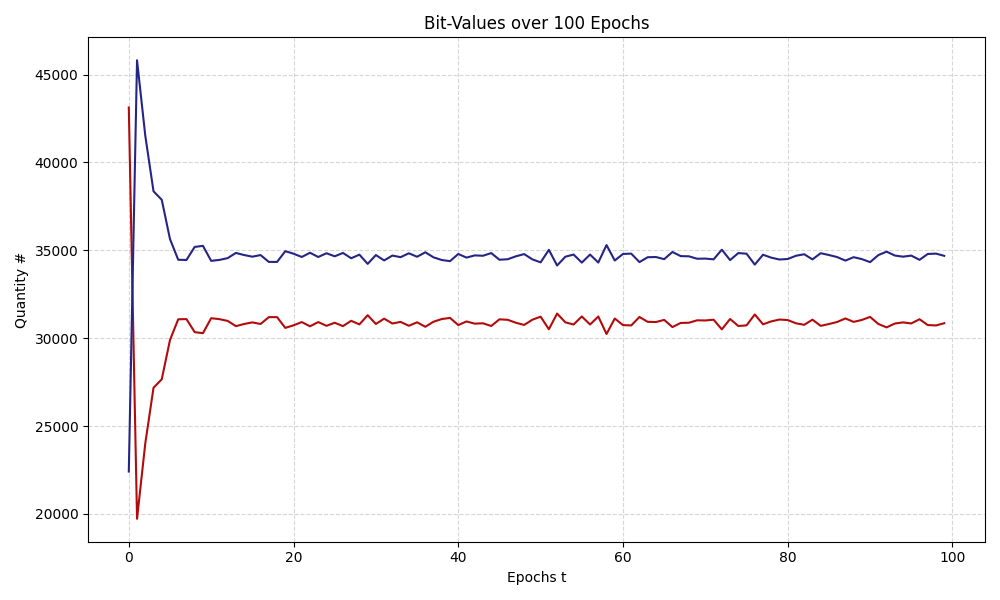

In [10]:
plt.close("all")

num_ones_per_epoch = np.sum(results, axis=(1, 2))
num_zeroes_per_epoch = results[0].size - num_ones_per_epoch

fig, ax = plt.subplots(figsize=(10, 6), num=" ")

ax.plot(range(num_epochs), num_ones_per_epoch, color="#b20b0b")
ax.plot(range(num_epochs), num_zeroes_per_epoch, color="#252585")

ax.set_title(f"Bit-Values over {num_epochs} Epochs")
ax.set_xlabel("Epochs t")
ax.set_ylabel("Quantity #")
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

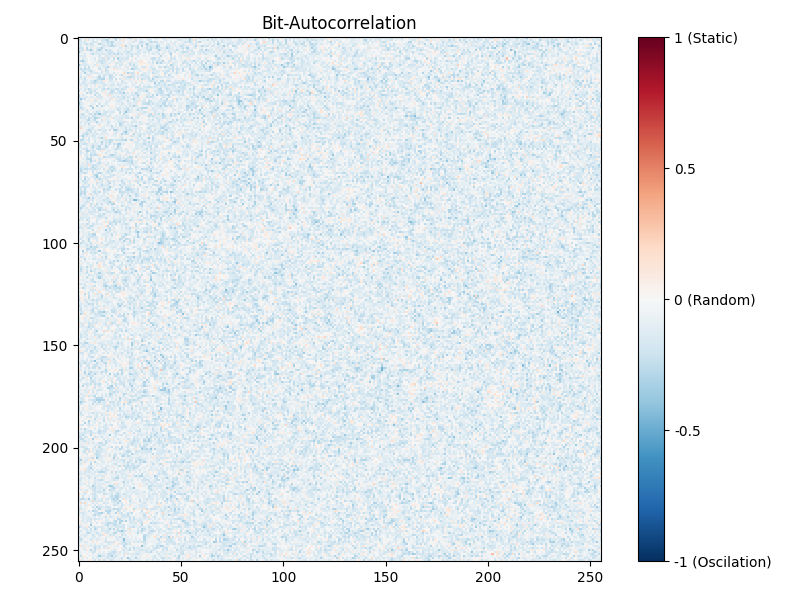

In [11]:
plt.close('all')

num_epochs, height, width = results.shape

flat_results = results.reshape(num_epochs, -1).astype(np.float32)

t_0 = flat_results[:-1]
t_1 = flat_results[1:]

cov = np.mean(t_0 * t_1, axis=0) - np.mean(t_0, axis=0) * np.mean(t_1, axis=0)
std_prod = np.std(t_0, axis=0) * np.std(t_1, axis=0)

with np.errstate(invalid='ignore', divide='ignore'):
    spatial_corr = np.nan_to_num(cov / std_prod, nan=0.0).reshape(height, width)

fig, ax = plt.subplots(figsize=(8, 6), num=" ")

img = ax.imshow(spatial_corr, cmap="RdBu_r", vmin=-1.0, vmax=1.0, interpolation="nearest")

ax.set_title("Bit-Autocorrelation")

cbar = fig.colorbar(img, ax=ax)
cbar.set_ticks([-1.0, -0.5, 0.0, 0.5, 1.0])
cbar.set_ticklabels(["-1 (Oscilation)", "-0.5", "0 (Random)", "0.5", "1 (Static)"])

plt.tight_layout()
plt.show()

In [ ]:
generator_index = 2

seen = set()

while True:
    generator = g[generator_index]

    state = generator.b64['data']

    if state in seen:
        print(f"Found Collision at {generator.epoch}")
        break

    seen.add(state)

    generator.step()

print(g[generator_index].epoch)

NameError: name 'g' is not defined